# What are the most demanded skills for the top 3 most popular data roles

In [ ]:
import ast
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns  

df = pd.read_csv('C:/Users/jhonn/Downloads/data_jobs.csv')

#Cleaning the date 
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
df_usa = df[df['job_country'] == 'United States'].copy()

In [3]:
df_skills = df_usa.explode('job_skills')


In [4]:
df_skills_count = df_skills.groupby(['job_skills','job_title_short']).size()

In [5]:
df_skills_count = df_skills_count.reset_index(name='skill_count')
df_skills_count

,job_skills,job_title_short,skill_count
0,airflow,Business Analyst,38
1,airflow,Cloud Engineer,27
2,airflow,Data Analyst,387
3,airflow,Data Engineer,4716
4,airflow,Data Scientist,1166
...,...,...,...
1865,zoom,Machine Learning Engineer,5
1866,zoom,Senior Data Analyst,50
1867,zoom,Senior Data Engineer,30
1868,zoom,Senior Data Scientist,25


In [6]:
df_skills_count = df_skills_count.sort_values('skill_count', ascending = False)

In [7]:
df_skills_count

,job_skills,job_title_short,skill_count
1209,python,Data Scientist,42379
1521,sql,Data Analyst,34452
1523,sql,Data Scientist,30034
455,excel,Data Analyst,27519
1243,r,Data Scientist,26022
...,...,...,...
553,gdpr,Software Engineer,1
554,ggplot2,Business Analyst,1
1843,wrike,Business Analyst,1
1839,workfront,Data Engineer,1


In [8]:
job_titles = df_skills_count['job_title_short'].unique().tolist()
job_titles = sorted(job_titles[:3])
job_titles 

['Data Analyst', 'Data Engineer', 'Data Scientist']

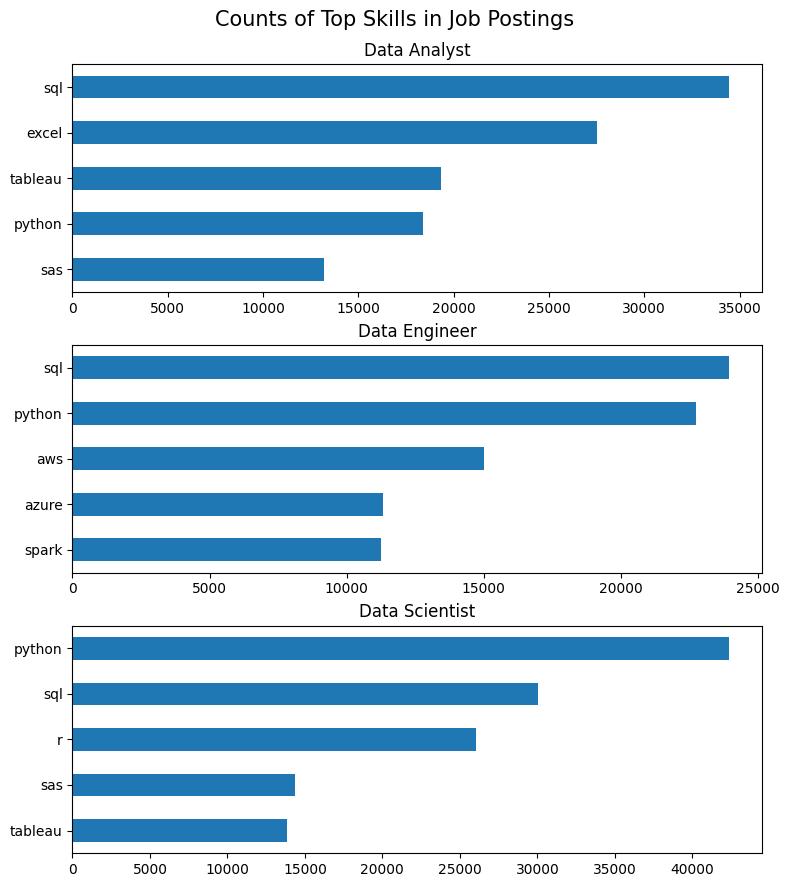

In [9]:
fig, ax = plt.subplots(len(job_titles), 1, figsize=(8, 3 * len(job_titles)), squeeze=False)
axes = ax.flatten()

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_count[df_skills_count['job_title_short'] == job_title].head(5)
    
    # Plot to the flattened axis array
    df_plot.plot(kind='barh', x='job_skills', y='skill_count', ax=axes[i], title=job_title)
    
    # Corrected method: invert_yaxis()
    axes[i].invert_yaxis()
    axes[i].set_ylabel('')
    
    legend = axes[i].legend()
    if legend:
        legend.set_visible(False)
    
fig.suptitle('Counts of Top Skills in Job Postings', fontsize=15)
fig.tight_layout(h_pad=0.5)
plt.show()

In [12]:
df_job_title_count = df_usa['job_title_short'].value_counts().reset_index(name='jobs_total')

In [14]:
df_skills_perc = pd.merge(df_skills_count, df_job_title_count, how= 'left', on='job_title_short')

df_skills_perc['skill_percent'] = 100 * df_skills_perc['skill_count']/df_skills_perc['jobs_total']
df_skills_perc

,job_skills,job_title_short,skill_count,jobs_total,skill_percent
0,python,Data Scientist,42379,58830,72.036376
1,sql,Data Analyst,34452,67816,50.802171
2,sql,Data Scientist,30034,58830,51.052184
3,excel,Data Analyst,27519,67816,40.578919
4,r,Data Scientist,26022,58830,44.232534
...,...,...,...,...,...
1865,gdpr,Software Engineer,1,1814,0.055127
1866,ggplot2,Business Analyst,1,7382,0.013546
1867,wrike,Business Analyst,1,7382,0.013546
1868,workfront,Data Engineer,1,35080,0.002851


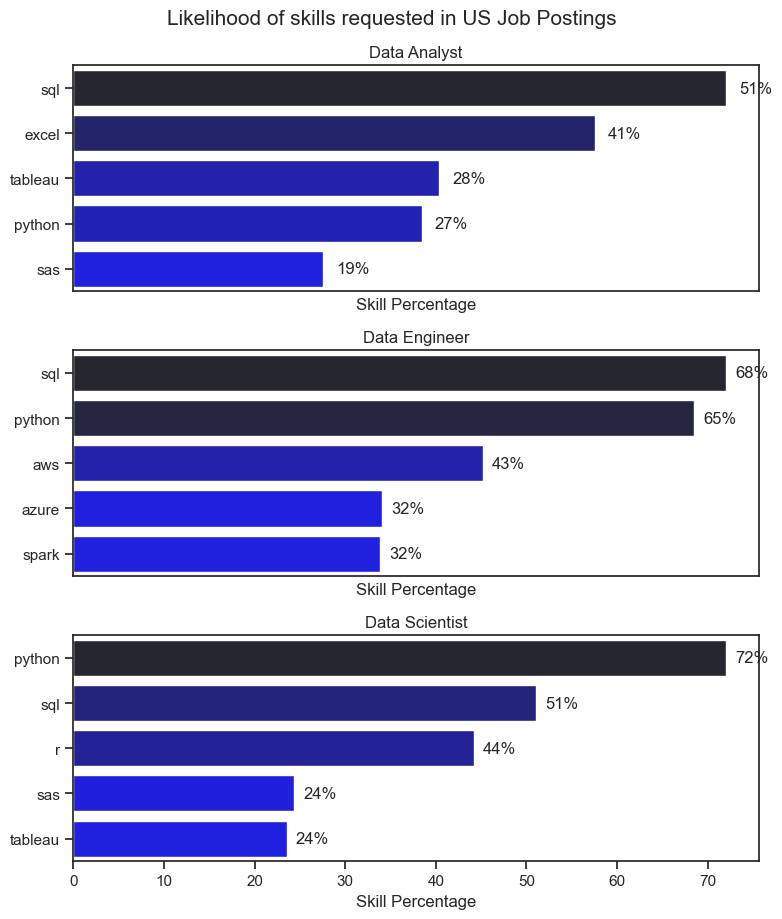

In [22]:
fig, ax = plt.subplots(len(job_titles), 1, figsize=(8, 3 * len(job_titles)), squeeze=False)
axes = ax.flatten()

sns.set_theme(style='ticks')

for i, job_title in enumerate(job_titles):
    df_plot = df_skills_perc[df_skills_perc['job_title_short'] == job_title].head(5)
    
    sns.barplot(
        data=df_plot, 
        x='skill_percent', 
        y='job_skills', 
        ax=axes[i], 
        hue='skill_count', 
        palette='dark:blue_r'
    )
    
    axes[i].set_title(job_title)
    axes[i].set_ylabel('')
    axes[i].set_xlabel('Skill Percentage')
    
    legend = axes[i].get_legend()
    if legend:
        legend.remove()
        
    # FIXED: Changed ax[i] -> axes[i] and fixed float format f'{v:.0f}%'
    for n, v in enumerate(df_plot['skill_percent']):
        axes[i].text(v + 1, n, f'{v:.0f}%', va='center')
    
    # FIXED: Changed ax[i] -> axes[i]
    if i != len(job_titles) - 1:
        axes[i].set_xticks([])

fig.tight_layout()
fig.suptitle('Likelihood of skills requested in US Job Postings', fontsize=15, y=1.02)
plt.show()